In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 随机种子 —— 保证结果可复现
np.random.seed(42)

## 1.Scaled Dot-Product Attention

$$
Attention(Q, K, V) = softmax(\frac{Q \cdot K^T}{\sqrt{d_k}} \cdot V)
$$

### 1.1 数值稳定型 Softmax 函数 —— 防止分子溢出

$$
\text{Softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum\limits_{j=1}^{n} e^{x_j - \max(x)}}
$$

### 1.2 注意力机制

$$
Attention(Q, K, V) = softmax(\frac{Q \cdot K^T}{\sqrt{d_k}} \cdot V)
$$

output shape: (5, 8)
output: 
[[-0.23  0.54  1.03  0.28 -0.32 -0.3  -0.76 -0.41]
 [ 0.04  1.15  0.42 -0.01 -0.56 -0.68  0.29  0.08]
 [ 0.05  1.9  -0.    0.22 -0.27 -0.95  0.73  0.39]
 [-0.17  0.62  1.1   0.03 -0.42 -0.41 -0.26 -0.09]
 [-0.13  0.44  0.8  -0.04 -0.8  -0.42  0.02 -0.35]]
weights shape: (5, 5)
weights: 
[[0.14 0.29 0.08 0.43 0.06]
 [0.19 0.02 0.29 0.11 0.39]
 [0.04 0.05 0.14 0.04 0.74]
 [0.34 0.14 0.09 0.32 0.11]
 [0.39 0.2  0.27 0.11 0.04]]
weights sum(should be 1): [1. 1. 1. 1. 1.]


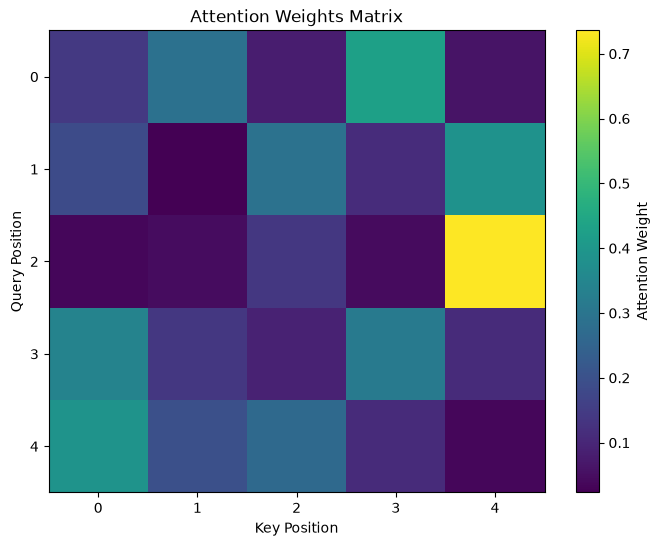

In [21]:
def softmax(x, axis=1):
    """数值稳定的softmax, 防止x_i过大, np.exp(x_i)分子溢出"""
    x_max = np.max(x, axis=axis, keepdims=True)     # keepdims用于保持维度，便于之后的softmax广播，比如(5, 8) -> (5, 1) 而不是默认False的(5,)
    exp_x = np.exp(x - x_max)       # 减去 x_max 防止溢出，但不影响结果
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    缩放点积注意力

    Q: Queries (seq_len_q, d_k)
    K: Keys    (seq_len_k, d_k)
    V: Values  (seq_len_v, d_v)
    mask: Optional mask (seq_len_q, seq_len_k)，布尔矩阵，通常上三角掩码（上三角为 1(屏蔽)，下三角为 0(保留)）
    """
    d_k = Q.shape[-1]       # Q 的最后一维维度 = d_k

    # 计算注意力分数 Q·K^T / √d_k
    scores = np.dot(Q, K.T) / np.sqrt(d_k)

    # 是否掩码 —— 让掩码部分为一个很大的负数，softmax 后几乎为 0
    if mask is not None:
        scores = scores + (mask * -1e9)

    # softmax 求权重
    attention_weights = softmax(scores, axis=-1)    # == axis=1，对每一行（每个 query）在 key 维度上归一化

    # 使用权重对 V 加权
    output = np.dot(attention_weights, V)

    return output, attention_weights

# 测试点积注意力
seq_len = 5
d_model = 8

Q = np.random.randn(seq_len, d_model)
K = np.random.randn(seq_len, d_model)
V = np.random.randn(seq_len, d_model)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print(f"output shape: {output.shape}")
np.set_printoptions(precision=2, suppress=True)     # np.array格式化，保留两位小数
print(f"output: \n{output:}")
print("="*50)
print(f"weights shape: {attn_weights.shape}")
print(f"weights: \n{attn_weights:}")
print(f"weights sum(should be 1): {attn_weights.sum(axis=1)}")

# 可视化
plt.figure(figsize=(8, 6))
plt.imshow(attn_weights, cmap="viridis", aspect="auto")     # 把二维数组化成图像
plt.colorbar(label="Attention Weight")      # 颜色条
plt.xlabel('Key Position')
plt.ylabel('Query Position')
plt.title('Attention Weights Matrix')
plt.show()

## # 2. Multi-Head Attention

$$
\text{MultiHead}(Q, K, V) = \text{Concat}(head_1, \cdots, head_h)W^O
$$

Multi-Head Attention:
Input Shape: (10, 64)
Output Shape: (10, 64)
Number of heads: 8
Dimension of per head: 8


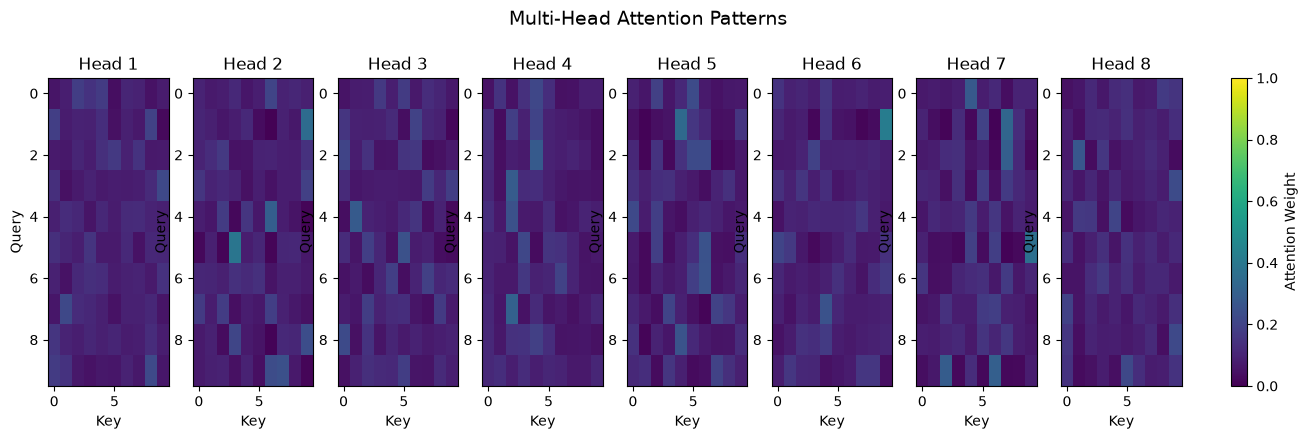

每一个头学会理解不同的模式/语义
不同的头捕获数据中不同的关系


In [22]:
class MultiHeadAttention:
    def __init__(self, d_model, num_heads):
        # 等价于 if d_model % num_heads != 0:    raise AssertionError
        assert d_model % num_heads == 0

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        # # 输入线性投影（所有头共享，先投影后分头）
        self.W_q = np.random.randn(d_model, d_model) * 0.1      # 乘一个小系数，让初始权重小而均匀(之前之前均值为 0，标准为 1，现在标准差为 0.1)，数值更稳定，防止梯度消失
        self.W_k = np.random.randn(d_model, d_model) * 0.1
        self.W_v = np.random.randn(d_model, d_model) * 0.1

        # 输出投影矩阵 W_o (d_model, d_model)
        self.W_o = np.random.randn(d_model, d_model) * 0.1

    def split_heads(self, x):
        """
        分头：(seq_len, d_model) --> (num_heads, seq_len, d_k)
        """
        seq_len = x.shape[0]
        x = x.reshape(seq_len, self.num_heads, self.d_k)
        # transpose 重排轴顺序，把"头"的维度放到最前面，这样就能用 Q[i] 很方便地取出第 i 个头的数据（shape (seq_len, d_k)），方便后续 for 循环逐个头做注意力
        # 新数组的第 0 轴 = 原数组的第 1 轴；新数组的第 1 轴 = 原数组的第 0 轴；新数组的第 2 轴 = 原数组的第 2 轴
        return x.transpose(1, 0, 2)     

    def combine_heads(self, x):
        """
        混合头: (num_heads, seq_len, d_k) --> (seq_len, d_model)
        """
        seq_len = x.shape[1]
        x = x.transpose(1, 0, 2)        # (seq_len, num_heads, d_k)
        return x.reshape(seq_len, self.d_model)

    def forward(self, Q, K, V, mask=None):
        """
        多头注意力前向传播
        Q, K, V: (seq_len, d_model)
        """
        # 线性投影
        Q = np.dot(Q, self.W_q.T)
        K = np.dot(K, self.W_k.T)
        V = np.dot(V, self.W_v.T)

        # 分头
        Q = self.split_heads(Q)         # (num_heads, seq_len, d_k)
        K = self.split_heads(K)
        V = self.split_heads(V)

        # 对每个头应用注意力机制
        head_outputs = []
        self.attention_weights = []

        for i in range(self.num_heads):     # self.num_heads = 8
            head_out, head_attn = scaled_dot_product_attention(
                Q[i], K[i], V[i], mask
            )
            head_outputs.append(head_out)
            self.attention_weights.append(head_attn)

        # 将各头输出堆叠成一个张量（新增"头"维度） —— combine_heads 要求输入三维数组，而目前 head_outputs 为 Python list，每一个元素为二维数组(seq_len, d_k)，stack 就是把这八个头对应的二维数组堆叠成一个三维数组
        heads = np.stack(head_outputs, axis=0)  # (num_heads, seq_len, d_k)

        # 混合头
        combined = self.combine_heads(heads)    # (seq_len, d_model)

        # 线性层投影
        output = np.dot(combined, self.W_o.T)

        return output

# 测试多头注意力
d_model = 64
num_heads = 8
seq_len = 10

mha = MultiHeadAttention(d_model, num_heads)

X = np.random.randn(seq_len, d_model)
output = mha.forward(X, X, X)       # Self-Attention

print(f"Multi-Head Attention:")
print(f"Input Shape: {X.shape}")
# print(f"X: \n{X}")
print(f"Output Shape: {output.shape}")
# print(f"output: \n{output}")
print(f"Number of heads: {num_heads}")
print(f"Dimension of per head: {mha.d_k}")

# 可视化
fig, axes = plt.subplots(1, num_heads, figsize=(16, 4))

for i, ax in enumerate(axes):
    attn = mha.attention_weights[i]
    im = ax.imshow(attn, cmap="viridis", aspect="auto", vmin=0, vmax=1)
    ax.set_title(f"Head {i+1}")
    ax.set_xlabel("Key")
    ax.set_ylabel("Query")

plt.colorbar(im, ax=axes, label="Attention Weight", fraction=0.046, pad=0.04)
plt.suptitle("Multi-Head Attention Patterns", fontsize=14, y=1.05)
plt.show()

print("每一个头学会理解不同的模式/语义")
print("不同的头捕获数据中不同的关系")

## 3. Position Encoding

$$
PE_{(pos, 2i)} = sin(\frac{pos}{10000^{2i/d_{model}}})
$$

$$
PE_{(pos, 2i+1)} = cos(\frac{pos}{10000^{2i/d_{model}}})
$$

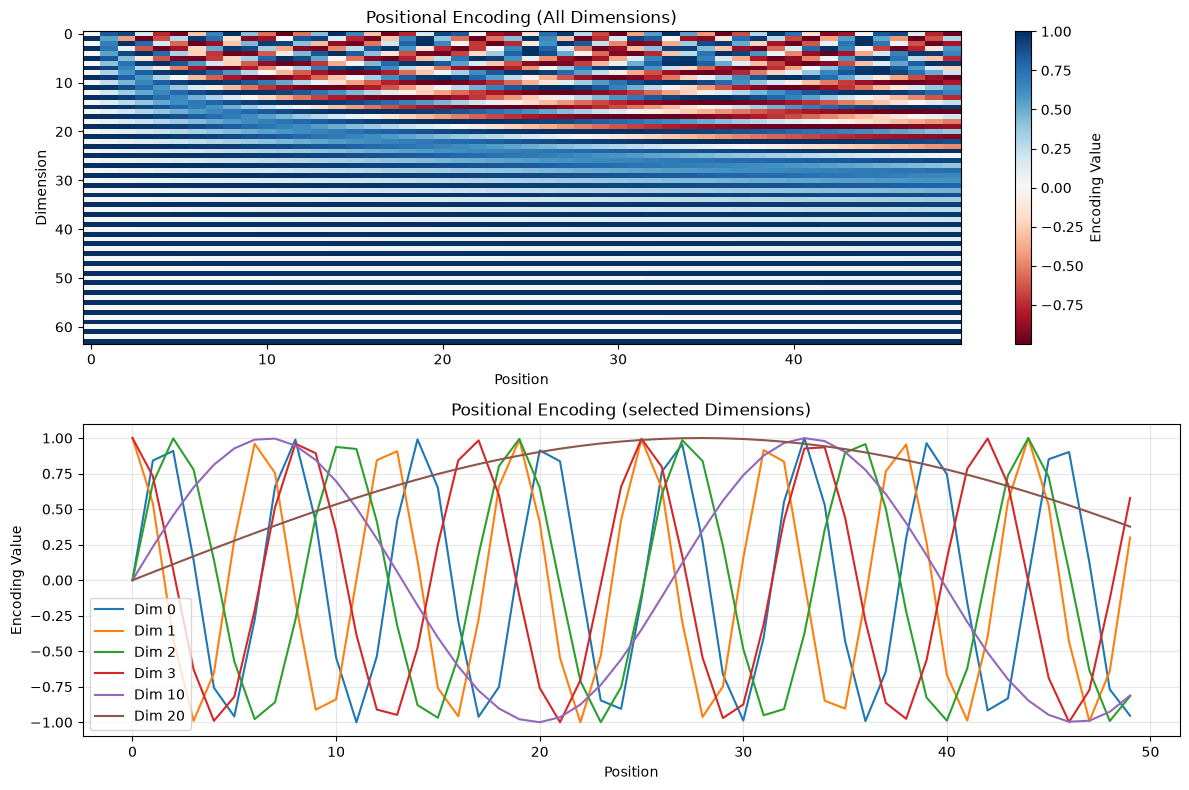

Positional encoding shape: (50, 64)
不同的频率（不同维度 i）在编码不同"尺度"的位置信息:
低频维度（小 i）：周期长、变化慢，适合编码粗粒度（远距离/大致位置）信息
高频维度（大 i）：周期短、变化快，适合编码细粒度（近距离/精确偏移）信息


In [23]:
def positional_encoding(seq_len, d_model):
    """
    创造正弦位置编码
    """
    pe = np.zeros((seq_len, d_model))       # 两层括号，因为内层传入的 (seq_len, d_model) 是一个元组

    position = np.arange(0, seq_len)[:, np.newaxis]     # np.newaxis 是 None 的别名，作用是在切片时增加一个新的轴（维度），在第 1 维（列方向加一个新轴，(seq_len) -> (seq_len, 1)，即每一行只有一个元素，方便之后的 position * div_term 广播计算

    # 用对数转换幂 10000^(2i/d_model) = exp^(ln(10000^(2i/d_model))) = exp^((2i * d_model)*ln(10000)) —— np.log + np.exp 是幂运算的安全等价写法（避免大数 10000 ** 大指数 溢出），而且计算上更稳定、更快，完全等价于 10000 ** (-2i * d_model)
    # 所以 1/10000^{2i/d_model} = 1/(exp^((2i * d_model) * ln(10000))) = exp^(-(2i * d_model) * ln(10000)) 
    div_term = np.exp(np.arange(0, d_model, 2) * -(np.log(10000.0) / d_model))

    # 应用正弦到偶数索引 —— 切片 start:stop:step
    pe[:, 0::2] = np.sin(position * div_term)

    # 应用余弦到奇数索引
    pe[:, 1::2] = np.cos(position * div_term)

    return pe       # (seq_len, d_model)

# 生成位置编码
seq_len = 50
d_model = 64
pe = positional_encoding(seq_len, d_model)

# 可视化位置编码
plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.imshow(pe.T, cmap='RdBu', aspect='auto')        # imshow只能花二维
plt.colorbar(label='Encoding Value')
plt.xlabel('Position')
plt.ylabel('Dimension')
plt.title('Positional Encoding (All Dimensions)')

plt.subplot(2, 1, 2)
# 低频维变化慢、高频维变化快
for i in [0, 1, 2, 3, 10, 20]:      # pe.shape(seq_len, d_model)
    plt.plot(pe[:, i], label=f'Dim {i}')
plt.xlabel('Position')
plt.ylabel('Encoding Value')
plt.title('Positional Encoding (selected Dimensions)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Positional encoding shape: {pe.shape}")
print("不同的频率（不同维度 i）在编码不同\"尺度\"的位置信息:")
print("低频维度（小 i）：周期长、变化慢，适合编码粗粒度（远距离/大致位置）信息")
print("高频维度（大 i）：周期短、变化快，适合编码细粒度（近距离/精确偏移）信息")


#### 3.1 子图一

1. **顶部（低维 0~5）**：颜色最杂乱最跳，红蓝条纹很细很密。说明这些维度频率最高、变化最快。
2. **中部（维度 20）**：条纹明显变粗，能看到一块块"周期"。
3. **下半部（维度 30+）**：几乎全是浅色横条，颜色非常均匀，几乎没有变化 → 这些维度频率极低（在 50 个位置里只完成不到一个完整周期）。
4. **最低维（接近 64）**：近乎一条平直的线（浅蓝），说明周期长到在 50 步内几乎不变。

**核心规律**：维度越高（纵轴向下），频率越低。

#### 3.2 子图二
核心结论:
正弦位置编码用一组不同频率的三角波，从粗到细组合出每个位置的唯一表示：
- **低频维（Dim 20、30+）**：告诉你"位置大概在序列的哪一段"（粗粒度，长程位置信息）
- **高频维（Dim 0、1、2、3）**：告诉你"精确到第几位"（细粒度，短程位置信息）
- **叠加效果**：模型同时看到粗和细的位置信号，就能唯一区分任意两个位置（这正是 PE 的核心要求）

## 4.Feed-Forward Network(FFN)

$$
\text{FFN}(x) = \text{max}(0, xW_1 + b_1)W2 + b_2
$$

In [24]:
class FeedForward:
    def __init__(self, d_model, d_ff):
        self.W1 = np.random.randn(d_model, d_ff) * 0.1
        self.b1 = np.zeros(d_ff)
        self.W2 = np.random.randn(d_ff, d_model) * 0.1
        self.b2 = np.zeros(d_model)

    def forward(self, x):
        # 第一层线性层 —— 带有非线性的 ReLU
        hidden = np.maximum(0, np.dot(x, self.W1) + self.b1)    # maximum 逐元素（element-wise）取最大值，返回一个和 x 同形状的数组，max 是标量间取最大

        # 第二层线性层
        output = np.dot(hidden, self.W2) + self.b2

        return output

# 测试前馈神经网络
d_model = 64
d_ff = 256      # 通常是 d_model 的 4 倍，隐藏层大小

ff = FeedForward(d_model, d_ff)
x = np.random.randn(10, d_model)    # (seq_len, d_model)
output = ff.forward(x)

print(f"Feed-Forward Network:")
print(f"Input: {x.shape}")
print(f"Hidden: ({x.shape[0]}, {d_ff})")
print(f"Output: {output.shape}")

Feed-Forward Network:
Input: (10, 64)
Hidden: (10, 256)
Output: (10, 64)


## 5.Layer-Normalization

- LayerNorm 对每个样本独立归一化，不依赖 batch，适合变长序列(如 NLP/Transformer)
- BatchNorm 依赖 batch 统计，常用于 CNN 等固定尺寸输入

$$
\text{LN}(x_i) = \gamma \odot \frac{x_i - \mu}{\sqrt{\sigma^2 + \epsilon}} + \beta
$$

- $\odot$: 逐元素（Hadamard）乘，γ 与 x 逐元素相乘
- $\gamma$（γ，初始化为全 1）：**缩放系数**（scale）。归一化把每行数据变成均值 0、方差 1，但这可能太"标准化"，限制了模型的表达能力。gamma 允许模型重新缩放每个维度的幅度。
- $\beta$（β，初始化为全 0）：**平移系数**（shift/bias）。允许模型重新平移每个维度的中心。
- $\epsilon$: 小常识防止除 0

为什么初始化为 γ=1、β=0？ 

因为初始时我们希望 LayerNorm 先保持"标准正态分布"的行为（相当于单位映射：均值为0方差1），即不改变归一化后的结果。这样模型从一开始是稳定的，然后在训练过程中通过反向传播学习最优的 γ 和 β（每个维度一个标量）。

**注意**：在实现里，γ 和 β 是固定的数组（np.ones/np.zeros），因为没有训练过程（梯度更新）。在真实框架（PyTorch 的 LayerNorm）里，它们是可学习参数。

In [25]:
class LayerNorm:
    def __init__(self, d_model, eps=1e-6):
        self.gamma = np.ones(d_model)
        self.beta = np.zeros(d_model)
        self.eps = eps

    def forward(self, x):
        mean = x.mean(axis=-1, keepdims=True)   # 对每个样本(每一行)沿特征维度(d_model)求均值 —— LayerNorm 是逐样本归一化

        std = x.std(axis=-1, keepdims=True)

        normalized = (x - mean) / (std + self.eps)
        output = self.gamma * normalized + self.beta

        return output

ln = LayerNorm(d_model)
x = np.random.randn(10, d_model) * 3 + 5    # Unnormalized，因为 randn 生成的就是标准化的，所以重新让 x 非标准化，对于无穷多的总体，均值为 5，标准差为 3
normalized = ln.forward(x)

print(f"Layer Normalization:")
print(f"Input mean: {x.mean():.4f}, std: {x.std():.4f}")    # 这里的 x 是总体取样的，不是无穷的总体，所以均值不为 5，标准差不为 3
print(f"Output: mean: {normalized.mean():.4f}, std: {normalized.std():.4f}")

Layer Normalization:
Input mean: 4.9676, std: 2.9628
Output: mean: 0.0000, std: 1.0000


## 6.Transformer Block

In [26]:
from yaml import Node


class TransformerBlock:
    def __init__(self, d_model, num_heads, d_ff):
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.norm1 = LayerNorm(d_model)
        self.ff = FeedForward(d_model, d_ff)
        self.norm2 = LayerNorm(d_model)

    def forward(self, x, mask=None):
        # 带残差连接的多头注意力
        attn_output = self.attention.forward(x, x, x, mask)
        x = self.norm1.forward(x + attn_output)

        # 带残差连接的前馈神经网络
        ff_output = self.ff.forward(x)
        x = self.norm2.forward(x + ff_output)

        return x

# 测试 Transformer 块
block = TransformerBlock(d_model=64, num_heads=8, d_ff=256)
x = np.random.randn(10, 64)
output = block.forward(x)

print(f"Transformer Block:")
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")
print(f"\nBlock contains:")
print(f"  1. Multi-Head Self-Attention")
print(f"  2. Layer Normalization")
print(f"  3. Feed-Forward Network")
print(f"  4. Residual Connections")

Transformer Block:
Input shape: (10, 64)
Output shape: (10, 64)

Block contains:
  1. Multi-Head Self-Attention
  2. Layer Normalization
  3. Feed-Forward Network
  4. Residual Connections


## 7.Causal(Masked) Selt-Attention for Autoregressive Models

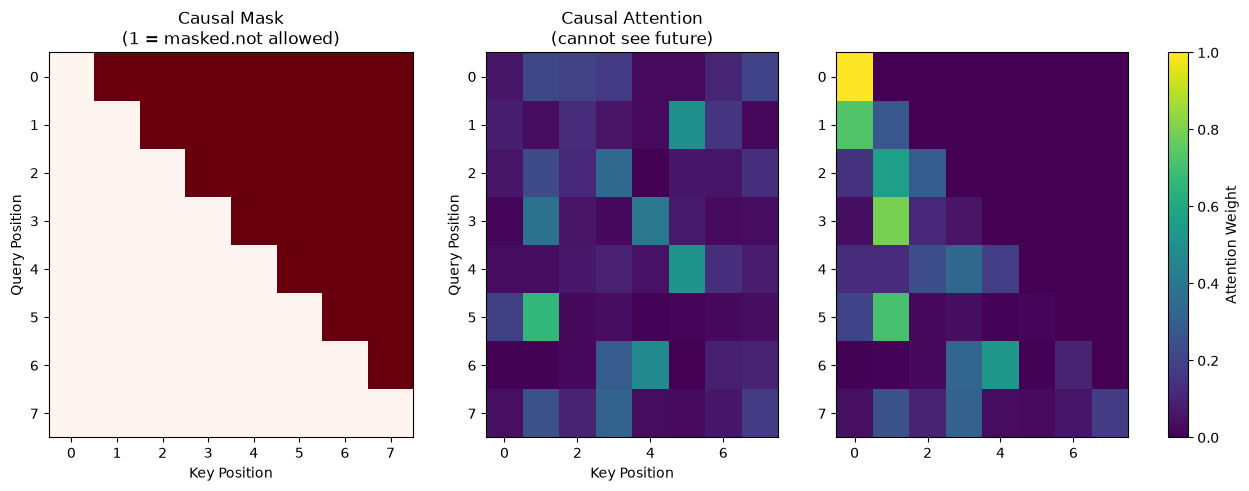

因果掩码很重要，因为：
  - 自回归生成（GPT，语言模型）
  - 阻止未来的 token 信息泄露
  - 每个位置只能注意它本身和它之前的位置


In [ ]:
def create_causal_mask(seq_len):
    """
    创造掩码防止注意到未来位置的信息
    """
    # k=0（默认）：保留主对角线及上方，k=1：从主对角线上方一行开始保留（即不含对角线），k=-1：保留主对角线下方一行开始（含对角线和第一条次对角线）
    mask = np.triu(np.ones((seq_len, seq_len)), k=1)
    return mask

# 测试因果注意力
seq_len = 8
causal_mask = create_causal_mask(seq_len)

Q = np.random.randn(seq_len, d_model)
K = np.random.randn(seq_len, d_model)
V = np.random.randn(seq_len, d_model)

# 没有掩码(双向) —— BERT
output_bi, attn_bi = scaled_dot_product_attention(Q, K, V)

# 有因果掩码(单向) —— GPT
output_causal, attn_causal = scaled_dot_product_attention(Q, K, V, mask=causal_mask)

# 可视化
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

# Causal mask
ax1.imshow(causal_mask, cmap="Reds", aspect="auto")
ax1.set_title("Causal Mask\n(1 = masked.not allowed)")
ax1.set_xlabel("Key Position")
ax1.set_ylabel("Query Position")

# 双向注意力
im2 = ax2.imshow(attn_bi, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax2.set_title("Bidirectional Attention\n(can be future)")
ax2.set_xlabel("Key Position")
ax2.set_ylabel("Query Position")

# Causal attention
im3 = ax3.imshow(attn_causal, cmap="viridis", aspect="auto", vmin=0, vmax=1)
ax2.set_title("Causal Attention\n(cannot see future)")
ax2.set_xlabel("Key Position")
ax2.set_ylabel("Query Position")

plt.colorbar(im3, ax=[ax2, ax3], label="Attention Weight")
plt.show()

print("因果掩码很重要，因为：")
print("  - 自回归生成（GPT，语言模型）")
print("  - 阻止未来的 token 信息泄露")
print("  - 每个位置只能注意它本身和它之前的位置")